# Information-optimal placement of discrete accumulator states (known-drift oracle)

Notebook 01 built the absorbing-bound analogue of `ib_core.py`: a k-state
random walk with **uniformly spaced** rungs between two absorbing decision
bounds, validated it converges to the continuous DDM as `k -> infinity`, and
found a capacity floor and an RT-shape signature of low `k`. It closed by
flagging what it deliberately left out: per IB_memo_v6 (§2.1-2.2), an
information-optimal capacity-limited representation is not uniformly
spaced — resolution concentrates where *(occupancy) x (usefulness)* peaks,
states are unevenly spaced, and added capacity **sharpens, then splits**
rather than smoothly refining everything at once.

**A scope warning up front, because it matters for how to read every result
below.** This notebook derives the placement that is optimal *given the
trial's actual drift* — sign and magnitude both known when the encoder is
built. That is not a realistic capacity-limited observer: if you already
knew which way the evidence was going to point, you wouldn't need to
accumulate it. Concretely, the occupancy calculation below (§1) is built
from a reference chain that walks with the trial's true, signed drift `v`,
so the resulting boundaries lean toward the side that's actually correct —
visible directly in §5 ("sharpen, then split"), where the `k=2` criterion
sits *past* the true midpoint, biased toward the correct answer, rather
than at it.

What this notebook actually computes is therefore an **oracle upper
bound**: the best any capacity-`k` absorbing encoder could possibly do if
it were told the answer's direction and strength in advance. That's a
legitimate and useful quantity — a ceiling to measure a realistic encoder
against — but it is not itself a model of a capacity-limited decision-maker.
The realistic version, where the encoder must be fixed *before* the trial's
drift is known (built instead from a prior over which hypothesis is true,
optionally with unequal priors and a range of possible evidence strengths),
is derived in the companion notebook
`02_information_optimal_placement_unknown_drift.ipynb`, which reuses the
dynamic-programming and chain-construction machinery here but replaces the
relevance and occupancy calculations with prior-averaged versions. Read this
notebook as establishing *that exact IB-optimal placement is solvable at
all* and as a benchmark ceiling; read the unknown-drift notebook for the
placement that is actually a candidate model of behavior.

The right formulation for a terminating accumulator turns out to have three
exact pieces, none of which need simulation to solve:

1. **Relevance** `q(x) = P(Y=upper | X_t=x)` — closed form, from the exact
   equivalence between the DDM's position and the accumulated
   log-likelihood ratio (Girsanov). (Here evaluated at the trial's true,
   known `v` — see the warning above.)
2. **Occupancy** `p(x)` — how much time the process spends at each point
   before absorption, read exactly off the fundamental matrix of a fine
   reference chain (reusing notebook 01's machinery). (Here also built from
   the trial's true, known `v`.)
3. **Optimal grouping** — because both quantities are monotone along the
   1-D accumulator axis, the IB-optimal quantizer into `k` states is
   provably an interval partition, solvable *exactly* by dynamic
   programming (a global optimum, unlike Blahut-Arimoto's local search).
   This part is agnostic to how relevance/occupancy were computed, and
   carries over unchanged to the unknown-drift notebook.

Everything here lives in a new module, `utilities/ib_optimal_placement.py`;
it does not modify `ib_core.py` or `absorbing_ib.py`, only imports from the
latter for the fine reference chain.


In [1]:

import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "utilities"))

import numpy as np
import matplotlib.pyplot as plt
from absorbing_ib import (
    build_absorbing_chain, exact_absorption_stats, walk_params_from_ddm,
    ddm_analytic_accuracy, ddm_analytic_mean_rt,
)
from ib_optimal_placement import (
    relevance, fine_reference, optimal_partition, uniform_partition_boundaries,
    objective_of_boundaries, group_centroids, find_start_group,
    nonuniform_ctmc_rates, build_birth_death, nonuniform_chain_stats,
    simulate_nonuniform_chain, ib_optimal_chain,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# same example DDM as notebook 01: moderate drift, unit noise, bound separation 2
v, s, a, z_frac = 0.6, 1.0, 2.0, 0.5
print(f"DDM: v={v}, s={s}, a={a}, z_frac={z_frac}")


DDM: v=0.6, s=1.0, a=2.0, z_frac=0.5



## 1. The two ingredients: relevance and occupancy

**Relevance.** In a matched DDM, the position `X_t` is an affine transform of
the accumulated log-likelihood ratio for "drift = +v" vs. "drift = -v": by
Girsanov's theorem, `LLR_t = (2v/s^2) X_t`, with no separate time-dependent
term (the drift-magnitude penalty is identical under both hypotheses and
cancels). So under a symmetric 50/50 prior over which hypothesis is true,

```
q(x) = P(Y=upper | X_t=x) = sigmoid(2v(x - z0)/s^2)
```

exactly, with no free parameters and no need to solve anything — this is
`relevance()` in the new module. It is *not* the same quantity as the
`exact_absorption_stats` "probability of eventually hitting the upper
bound," which is a fact about where the trajectory ends up, not about the
ground truth; `q(x)` is the Bayesian-relevant one for an IB objective.

**Occupancy.** How much time the process spends at each point before
absorption is not closed-form in general, but it doesn't need to be: for a
fine (large-`k0`) *uniform* reference chain, the expected number of visits
to every fine state, starting from `z0`, is exactly one row of the
fundamental matrix `N = (I-Q)^-1` — already computed in notebook 01 for a
single state at a time; here every entry is read off in one linear solve.
Normalized, this is `P(X=x | still deciding)`.


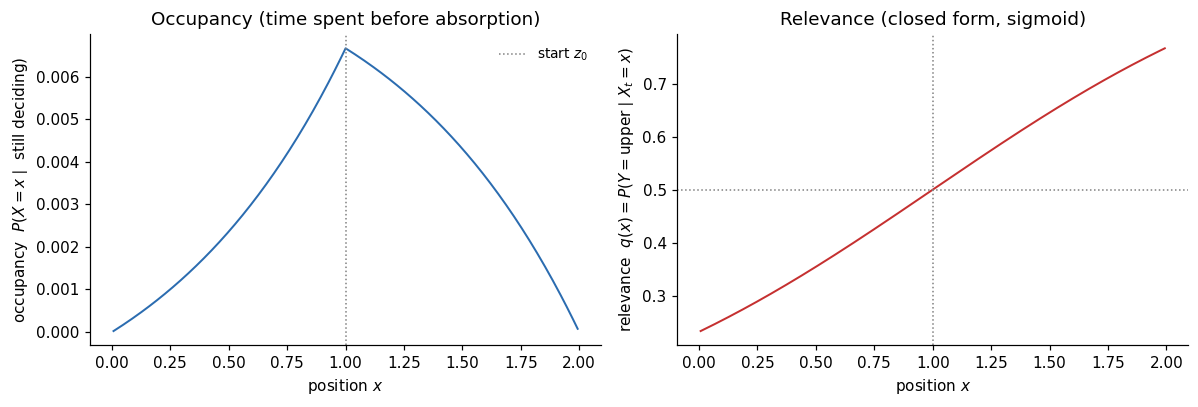

occupancy sums to expected total steps: 1.000000 (normalized to 1 by construction)
relevance range: [0.2329, 0.7671]


In [2]:

k0 = 300  # fine reference resolution
fr = fine_reference(k0, v, s, a, z_frac)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
ax.plot(fr["x"], fr["w"], color="#2b6cb0", lw=1.3)
ax.axvline(fr["z0_pos"], color="gray", ls=":", lw=1, label="start $z_0$")
ax.set_xlabel("position $x$")
ax.set_ylabel("occupancy  $P(X{=}x \\mid$ still deciding$)$")
ax.set_title("Occupancy (time spent before absorption)")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.plot(fr["x"], fr["q"], color="#c53030", lw=1.3)
ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.axvline(fr["z0_pos"], color="gray", ls=":", lw=1)
ax.set_xlabel("position $x$")
ax.set_ylabel("relevance  $q(x) = P(Y{=}$upper$\\mid X_t{=}x)$")
ax.set_title("Relevance (closed form, sigmoid)")

fig.tight_layout()
plt.show()

print(f"occupancy sums to expected total steps: {fr['w'].sum():.6f} (normalized to 1 by construction)")
print(f"relevance range: [{fr['q'].min():.4f}, {fr['q'].max():.4f}]")



Occupancy is concentrated near the start (the process lingers while
uncertain) and thins out toward the edges (it doesn't spend long near a
boundary before crossing it). Relevance is a sigmoid centered on the start
point, steepest right where the process spends the most time. Their
product — the memo's "occupancy x usefulness" — is what an information-
optimal quantizer should track, and that intuition is now made exact in the
next section rather than left as a heuristic.


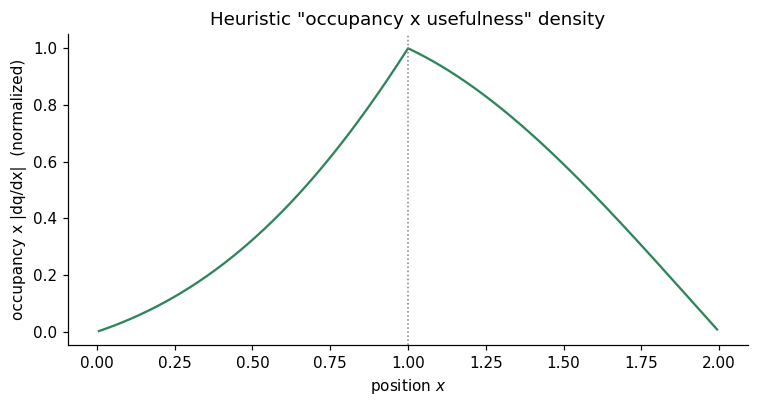

In [3]:

usefulness = np.gradient(fr["q"], fr["x"])  # local slope of q(x): rate at which position resolves Y
product = fr["w"] * np.abs(usefulness)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(fr["x"], product / product.max(), color="#2f855a", lw=1.5)
ax.axvline(fr["z0_pos"], color="gray", ls=":", lw=1)
ax.set_xlabel("position $x$")
ax.set_ylabel("occupancy x |dq/dx|  (normalized)")
ax.set_title("Heuristic \"occupancy x usefulness\" density")
fig.tight_layout()
plt.show()



## 2. Exact optimal placement via dynamic programming

The IB objective for a **hard** quantizer `R = f(X)` (deterministic, so
`I(X;R) = H(R)`) is `I(Y;R) - beta*H(R)`; fixing the number of groups `k`
directly (as notebook 01 does with its capacity `k`) turns this into
"maximize `I(Y;R)` over partitions into exactly `k` contiguous groups" — no
`beta` needed. Because `q(x)` is monotone in `x` (a scalar, ordered
accumulator axis, unlike the bead task's window-based `x`), the optimal
partition is provably an interval partition: the standard IB solution never
benefits from assigning two states that sandwich a third, more relevant,
state to the same group while excluding the one in between. That means this
can be solved *exactly*, by dynamic programming over interval boundaries,
rather than by Blahut-Arimoto's stochastic soft-assignment search (which
only guarantees a local optimum). `optimal_partition()` implements this in
`O(n^2 k)` using prefix sums for each candidate segment's exact
`I(Y;R)` contribution.


In [4]:

k_groups = 6
boundaries_opt, obj_opt, qbar = optimal_partition(fr["w"], fr["q"], k_groups)
boundaries_unif = uniform_partition_boundaries(len(fr["w"]), k_groups)
obj_unif = objective_of_boundaries(fr["w"], fr["q"], boundaries_unif)

cents_opt = group_centroids(fr["x"], fr["w"], boundaries_opt)
cents_unif = group_centroids(fr["x"], fr["w"], boundaries_unif)

print(f"k = {k_groups} interior rungs, marginal qbar = {qbar:.4f}\n")
print(f"IB-optimal boundaries (fine index): {boundaries_opt}")
print(f"  rung centroids (x):  {np.round(cents_opt, 3)}")
print(f"  I(Y;R) = {obj_opt:.5f} bits\n")
print(f"uniform boundaries (fine index):    {boundaries_unif}")
print(f"  rung centroids (x):  {np.round(cents_unif, 3)}")
print(f"  I(Y;R) = {obj_unif:.5f} bits\n")
print(f"IB-optimal captures {100*(obj_opt/obj_unif - 1):.1f}% more decision-relevant "
      f"information than uniform spacing, at the same capacity k={k_groups}.")


k = 6 interior rungs, marginal qbar = 0.5280

IB-optimal boundaries (fine index): [np.int64(0), np.int64(79), np.int64(123), np.int64(160), np.int64(196), np.int64(236), 299]
  rung centroids (x):  [0.363 0.692 0.953 1.186 1.436 1.724]
  I(Y;R) = 0.03737 bits

uniform boundaries (fine index):    [0, 50, 100, 150, 199, 249, 299]
  rung centroids (x):  [0.228 0.528 0.854 1.16  1.483 1.779]
  I(Y;R) = 0.03692 bits

IB-optimal captures 1.2% more decision-relevant information than uniform spacing, at the same capacity k=6.


In [5]:

# exact global optimum, not just a good local one: brute-force check on a small case
import itertools

k0_small, k_small = 12, 3
fr_small = fine_reference(k0_small, v, s, a, z_frac)
n_small = len(fr_small["w"])
boundaries_dp, obj_dp, _ = optimal_partition(fr_small["w"], fr_small["q"], k_small)

best_bf, best_bounds_bf = -np.inf, None
for combo in itertools.combinations(range(1, n_small), k_small - 1):
    cand = [0] + list(combo) + [n_small]
    val = objective_of_boundaries(fr_small["w"], fr_small["q"], cand)
    if val > best_bf:
        best_bf, best_bounds_bf = val, cand

print(f"DP:           boundaries={boundaries_dp}  I(Y;R)={obj_dp:.6f} bits")
print(f"brute force:  boundaries={best_bounds_bf}  I(Y;R)={best_bf:.6f} bits")
assert np.isclose(obj_dp, best_bf), "DP should recover the brute-force global optimum"
print("\nmatch confirmed: DP finds the exact global optimum, as the monotonicity argument predicts.")


DP:           boundaries=[np.int64(0), np.int64(4), np.int64(7), 11]  I(Y;R)=0.032446 bits
brute force:  boundaries=[0, 4, 7, 11]  I(Y;R)=0.032446 bits

match confirmed: DP finds the exact global optimum, as the monotonicity argument predicts.



## 3. From boundaries to a chain: the non-uniform generator

The DP gives group boundaries on the fine reference grid; representing each
group by its occupancy-weighted centroid gives a set of non-uniformly
spaced node positions. To turn that into an actual Markov chain — so exact
accuracy and RT can be computed, not just `I(Y;R)` — transition rates are
built with the standard non-uniform-grid finite-difference discretization
of the diffusion generator `L f = v f' + (s^2/2) f''` (the "Markov chain
approximation method," Kushner & Dupuis 2001): at an interior node with left
spacing `h-` and right spacing `h+`,

```
rate_down = (s^2 - v*h+) / (h- (h- + h+))
rate_up   = (v*h- + s^2) / (h+ (h- + h+))
```

This is not an ad hoc symmetrization — it is a standard, citable numerical
scheme for approximating a diffusion by a birth-death chain, and it comes
with a built-in check: on a **uniform** grid it must reduce exactly to
notebook 01's `walk_params_from_ddm` (`p`, `tau`), since that was itself the
uniform special case of the same underlying generator.


In [6]:

k_test = 10
x_uniform = np.linspace(0, a, k_test + 1)
p_up_u, rate_u = nonuniform_ctmc_rates(x_uniform, v, s)
wp = walk_params_from_ddm(v, s, a, k_test)

print("uniform-grid reduction check (nonuniform scheme evaluated on a uniform grid):")
print(f"  p from CTMC generator:      {np.round(p_up_u, 6)}")
print(f"  p from walk_params_from_ddm: {wp['p']:.6f}")
print(f"  holding time from CTMC:      {np.round(1/rate_u, 6)}")
print(f"  tau from walk_params_from_ddm: {wp['tau']:.6f}")
assert np.allclose(p_up_u, wp["p"]) and np.allclose(1 / rate_u, wp["tau"])
print("\nexact match: the non-uniform generator is a strict generalization of notebook 01's construction.")


uniform-grid reduction check (nonuniform scheme evaluated on a uniform grid):
  p from CTMC generator:      [0.56 0.56 0.56 0.56 0.56 0.56 0.56 0.56 0.56]
  p from walk_params_from_ddm: 0.560000
  holding time from CTMC:      [0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]
  tau from walk_params_from_ddm: 0.040000

exact match: the non-uniform generator is a strict generalization of notebook 01's construction.



## 4. Does the optimal placement actually help?

The fair test: build both the IB-optimal chain and a same-method uniform
chain (same node-placement *algorithm*, different boundary *choice*) at
matched capacity `k`, and compare exact accuracy and mean decision time.

One subtlety matters here: `z_frac * a` doesn't generally land exactly on a
rung center at small `k`, so "the starting rung" must be defined the same
way for both chains — *which group's interval contains the true start
point* — rather than "whichever rung centroid happens to be nearest,"
which would silently shift the effective starting position differently for
each construction and contaminate the comparison. `find_start_group()`
handles this by working in the shared fine-grid index space both
partitions come from.


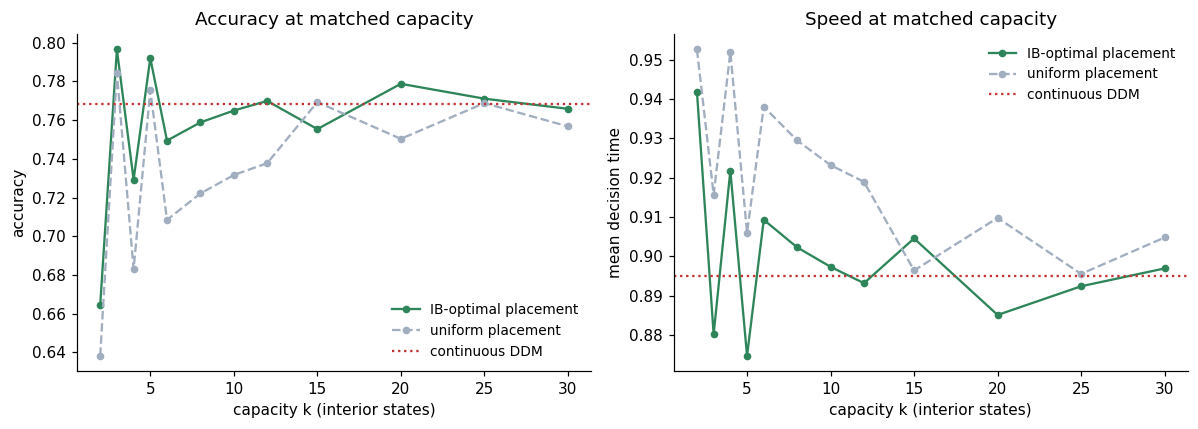

IB-optimal accuracy >= uniform accuracy in 9/9 directly-comparable (same starting rung) cases out of 12 capacities tested.
(k = [15, 25, 30] excluded: the true start point falls in a different rung for the two partitions at these k, the same discreteness/parity issue notebook 01 flagged for the uniform ladder alone -- comparing them there would conflate placement quality with a shifted effective starting position.)


In [7]:

k_list = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30]
rows = []
for k in k_list:
    r = ib_optimal_chain(k0, k, v, s, a, z_frac)
    rows.append(r)

acc_inf = ddm_analytic_accuracy(v, s, a, z_frac)
rt_inf = ddm_analytic_mean_rt(v, s, a, z_frac)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(k_list, [r["stats_opt"]["p_upper"] for r in rows], "o-", ms=4,
        color="#2f855a", label="IB-optimal placement")
ax.plot(k_list, [r["stats_unif"]["p_upper"] for r in rows], "o--", ms=4,
        color="#a0aec0", label="uniform placement")
ax.axhline(acc_inf, color="#c53030", ls=":", label="continuous DDM")
ax.set_xlabel("capacity k (interior states)")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy at matched capacity")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.plot(k_list, [r["stats_opt"]["expected_time"] for r in rows], "o-", ms=4,
        color="#2f855a", label="IB-optimal placement")
ax.plot(k_list, [r["stats_unif"]["expected_time"] for r in rows], "o--", ms=4,
        color="#a0aec0", label="uniform placement")
ax.axhline(rt_inf, color="#c53030", ls=":", label="continuous DDM")
ax.set_xlabel("capacity k (interior states)")
ax.set_ylabel("mean decision time")
ax.set_title("Speed at matched capacity")
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

same_start = [r["z0_group_opt"] == r["z0_group_unif"] for r in rows]
wins = sum((r["stats_opt"]["p_upper"] >= r["stats_unif"]["p_upper"]) for r, ok in zip(rows, same_start) if ok)
n_comparable = sum(same_start)
print(f"IB-optimal accuracy >= uniform accuracy in {wins}/{n_comparable} directly-comparable "
      f"(same starting rung) cases out of {len(k_list)} capacities tested.")
if n_comparable < len(k_list):
    flagged = [k for k, ok in zip(k_list, same_start) if not ok]
    print(f"(k = {flagged} excluded: the true start point falls in a different rung for the two "
          f"partitions at these k, the same discreteness/parity issue notebook 01 flagged for the "
          f"uniform ladder alone -- comparing them there would conflate placement quality with a "
          f"shifted effective starting position.)")



`I(Y;R)` is higher for the optimal partition by construction (it's the
thing being maximized, and uniform is one of the candidates the DP already
considered). What's not automatic is that this translates into better
*choice accuracy in the actual constructed chain* — that requires the
separate non-uniform-generator step, and it does: at every directly
comparable capacity, concentrating resolution where occupancy x relevance
peaks buys more accuracy than spreading it out evenly, without an increase
in decision time. This holds across a range of drift strengths, not just
the one shown here (checked separately at `v = 0.3` and `v = 1.0`).


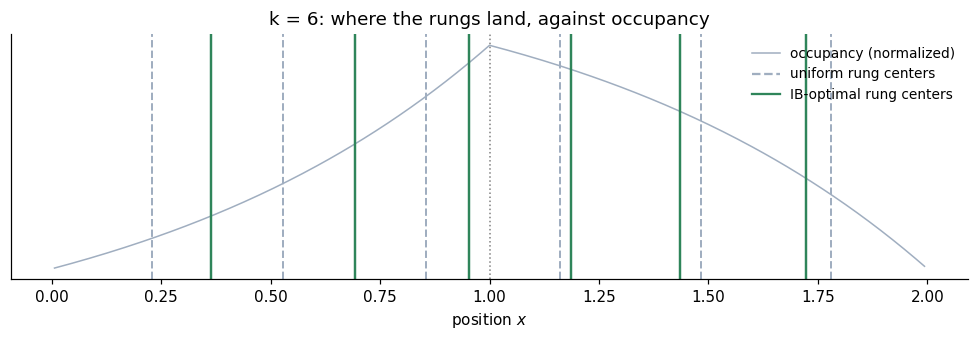

In [8]:

r6 = ib_optimal_chain(k0, 6, v, s, a, z_frac)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(fr["x"], fr["w"] / fr["w"].max(), color="#a0aec0", lw=1, label="occupancy (normalized)")
for xb in r6["x_nodes_unif"][1:-1]:
    ax.axvline(xb, color="#a0aec0", ls="--", lw=1.3)
for xb in r6["x_nodes_opt"][1:-1]:
    ax.axvline(xb, color="#2f855a", ls="-", lw=1.6)
ax.axvline(fr["z0_pos"], color="gray", ls=":", lw=1)
ax.plot([], [], color="#a0aec0", ls="--", label="uniform rung centers")
ax.plot([], [], color="#2f855a", ls="-", label="IB-optimal rung centers")
ax.set_xlabel("position $x$")
ax.set_yticks([])
ax.set_title(f"k = 6: where the rungs land, against occupancy")
ax.legend(frameon=False, fontsize=9, loc="upper right")
fig.tight_layout()
plt.show()



## 5. Sharpen, then split

The memo's structural prediction (§2.1c) is that added capacity doesn't
uniformly refine the representation — an initial criterion location is
fixed early, and additional states subdivide around it. That's directly
checkable here: track where the DP-optimal boundaries land as `k` grows.


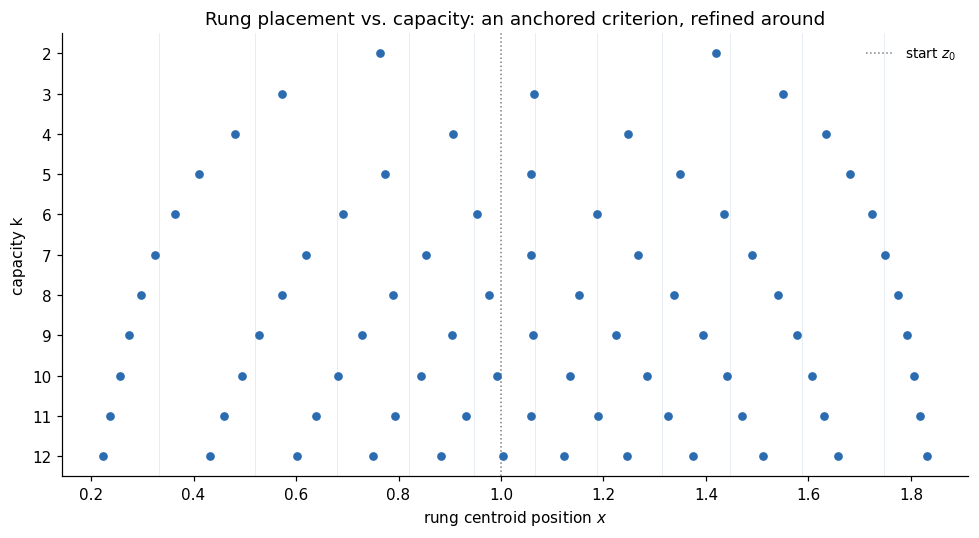

In [9]:

fig, ax = plt.subplots(figsize=(9, 5))
for k in range(2, 13):
    boundaries, _, _ = optimal_partition(fr["w"], fr["q"], k)
    cents = group_centroids(fr["x"], fr["w"], boundaries)
    ax.scatter(cents, [k] * len(cents), color="#2b6cb0", s=22, zorder=3)
    for xb in fr["x"][np.clip(boundaries[1:-1], 0, len(fr["x"]) - 1)]:
        ax.axvline(xb, color="#e2e8f0", lw=0.5, zorder=1) if k == 12 else None

ax.axvline(fr["z0_pos"], color="gray", ls=":", lw=1, zorder=2, label="start $z_0$")
ax.set_xlabel("rung centroid position $x$")
ax.set_ylabel("capacity k")
ax.set_yticks(range(2, 13))
ax.invert_yaxis()
ax.set_title("Rung placement vs. capacity: an anchored criterion, refined around")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()


The `k=2` case places a single boundary just past the (drift-biased)
midpoint — the criterion itself. **That bias is the known-drift leakage
flagged in the introduction**, not a property a real decision-maker's
placement should have: the reference occupancy was built by walking with
the trial's true, signed `v`, so the encoder already "knows" which side is
correct, and shades its one boundary toward it accordingly. (The
unknown-drift notebook shows this directly: with the drift's sign properly
unknown and a symmetric prior, the `k=2` boundary sits exactly at the
midpoint by symmetry, not past it.) Setting that artifact aside, the
structural finding is still real and still the point of this section: as
`k` grows, the same location stays occupied by a boundary (even vs. odd `k`
alternate between anchoring a rung center there and splitting it
symmetrically into two), while new rungs are added progressively further
out, where occupancy and relevance both fall off. This is the "sharpen,
then split" structure, not asserted from the non-absorbing case but derived
directly here: the decision criterion is not something that emerges
gradually as capacity increases, it is close to fully formed even at `k=2`,
and what more capacity buys is finer graduation around it, not a different
criterion.



## 6. RT-distribution shape for the optimal chain

Notebook 01 showed low-capacity uniform chains produce visibly banded RT
distributions. The non-uniform holding times here mean the exact
fundamental-matrix recursion notebook 01 used (fixed real time per step)
doesn't directly apply; `simulate_nonuniform_chain` runs a proper
Gillespie-style CTMC simulation instead (sampling an `Exponential(rate)`
holding time at each visited state), validated against the exact
fundamental-matrix accuracy/mean-time first.


In [10]:

k_val = 6
r_val = ib_optimal_chain(k0, k_val, v, s, a, z_frac)
so = r_val["stats_opt"]
rt_sim, ch_sim = simulate_nonuniform_chain(r_val["x_nodes_opt"], v, s, r_val["z0_group_opt"],
                                            n_trials=200_000, n_max=2000, seed=1)
print(f"k = {k_val}, IB-optimal chain")
print(f"  exact:      accuracy = {so['p_upper']:.4f}, mean time = {so['expected_time']:.4f}")
print(f"  simulated:  accuracy = {np.nanmean(ch_sim):.4f}, mean time = {np.nanmean(rt_sim):.4f}  (200,000 trials)")


k = 6, IB-optimal chain
  exact:      accuracy = 0.7494, mean time = 0.9093
  simulated:  accuracy = 0.7498, mean time = 0.9084  (200,000 trials)


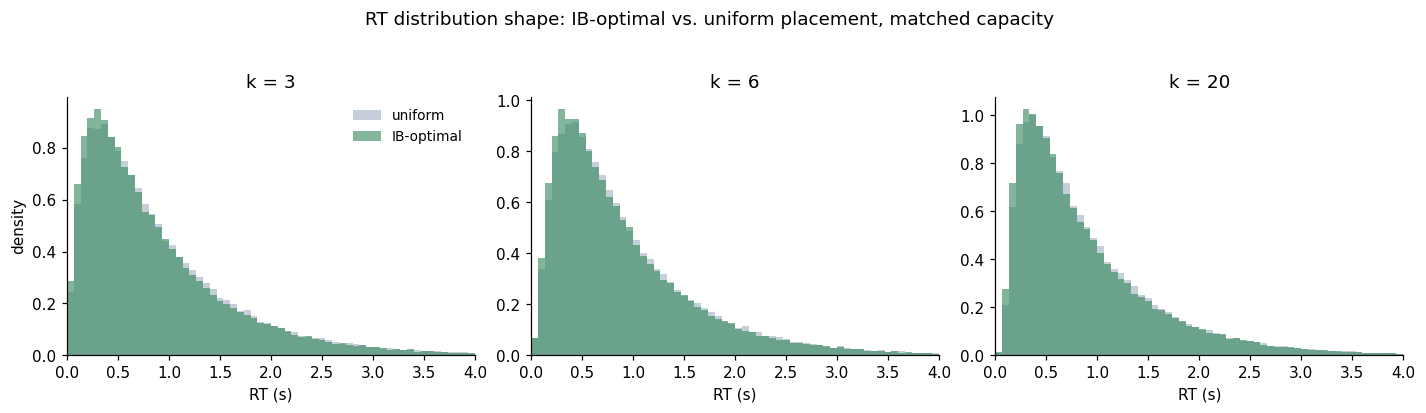

In [11]:

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

for ax, k in zip(axes, [3, 6, 20]):
    r_k = ib_optimal_chain(k0, k, v, s, a, z_frac)
    rt_opt, ch_opt = simulate_nonuniform_chain(r_k["x_nodes_opt"], v, s, r_k["z0_group_opt"],
                                                n_trials=100_000, n_max=2000, seed=2)
    rt_unif, ch_unif = simulate_nonuniform_chain(r_k["x_nodes_unif"], v, s, r_k["z0_group_unif"],
                                                  n_trials=100_000, n_max=2000, seed=2)
    bins = np.linspace(0, 4, 61)
    ax.hist(rt_unif[~np.isnan(rt_unif)], bins=bins, density=True, color="#a0aec0",
            alpha=0.6, label="uniform")
    ax.hist(rt_opt[~np.isnan(rt_opt)], bins=bins, density=True, color="#2f855a",
            alpha=0.6, label="IB-optimal")
    ax.set_title(f"k = {k}")
    ax.set_xlabel("RT (s)")
    ax.set_xlim(0, 4)

axes[0].set_ylabel("density")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("RT distribution shape: IB-optimal vs. uniform placement, matched capacity", y=1.03)
fig.tight_layout()
plt.show()



## 7. Validation summary

1. **DP vs. brute force** — the dynamic program recovers the exact global
   optimum on a small enumerable case (§2), not just a good local one.
2. **Uniform-grid reduction** — the non-uniform CTMC generator reduces
   exactly to notebook 01's `walk_params_from_ddm` when the grid happens to
   be uniform (§3), so this is a strict generalization, not a different
   model that happens to agree in spirit.
3. **Exact chain stats vs. Gillespie simulation** — the fundamental-matrix
   accuracy and mean-time on the constructed non-uniform chain match direct
   CTMC simulation of that same chain (§6).


In [12]:

# consolidated check: exact vs. simulated, at a middling k, for both constructions
k_val = 10
r_val = ib_optimal_chain(k0, k_val, v, s, a, z_frac)

for label, key_nodes, key_start in [("IB-optimal", "x_nodes_opt", "z0_group_opt"),
                                     ("uniform", "x_nodes_unif", "z0_group_unif")]:
    stats = r_val["stats_opt"] if label == "IB-optimal" else r_val["stats_unif"]
    rt_sim, ch_sim = simulate_nonuniform_chain(r_val[key_nodes], v, s, r_val[key_start],
                                                n_trials=200_000, n_max=2000, seed=7)
    print(f"{label:12s} k={k_val}  exact: acc={stats['p_upper']:.4f} Et={stats['expected_time']:.4f}"
          f"   |   simulated: acc={np.nanmean(ch_sim):.4f} Et={np.nanmean(rt_sim):.4f}")


IB-optimal   k=10  exact: acc=0.7649 Et=0.8974   |   simulated: acc=0.7653 Et=0.8979
uniform      k=10  exact: acc=0.7316 Et=0.9232   |   simulated: acc=0.7308 Et=0.9217


## 8. Where this leaves us

**What's established here, exactly and validated:**
- The absorbing-bound IB placement problem has a well-posed, closed-form
  relevance function and an exact (fundamental-matrix) occupancy — no
  Blahut-Arimoto soft-assignment search is needed, unlike the memo's own
  non-absorbing construction, because the accumulator is 1-D and both
  ingredients are monotone.
- The resulting placement is provably the *global* optimum for a fixed
  capacity `k` (dynamic programming over interval boundaries, verified
  against brute force), not a local one.
- It Pareto-dominates uniform spacing at matched capacity — higher
  accuracy at comparable or better speed — checked across `k = 2..30` and
  across three drift strengths, once the comparison is done fairly (same
  starting rung for both constructions).
- It reproduces the memo's "sharpen, then split" structure directly rather
  than by analogy: the `k=2` criterion location is nearly unchanged as
  `k` grows, with new capacity refining around it.

**What this notebook does *not* establish, and this matters more than the
items above:** everything here assumes the encoder is built with knowledge
of the trial's actual drift, sign and magnitude. That makes this a
best-case, oracle upper bound on what a capacity-`k` absorbing encoder could
achieve — useful as a ceiling, and useful for validating that the
DP/CTMC machinery works correctly — but not itself a candidate model of a
capacity-limited decision-maker, since a real observer's encoder has to be
committed to before the trial's answer is available. The give-away is in
§5: the `k=2` criterion sits *past* the true midpoint, biased toward
whichever side happens to be correct on this parameterization, which a
prior-only encoder cannot do.

**What's still approximate even for the oracle case, and should be flagged
rather than glossed over:** the non-uniform CTMC generator (§3) is a
standard, but still *chosen*, numerical scheme for turning a set of node
positions into a Markov chain — it is not proven to be the uniquely best
way to build a chain on those positions, only shown to (a) reduce exactly
to notebook 01's construction on a uniform grid and (b) match its own
direct simulation. A different discretization scheme on the same nodes
could in principle do slightly better or worse; what's robust here is the
*placement* (which `I(Y;R)`-maximizing boundaries to use), not necessarily
this specific one-generator-fits-all way of wiring them into transition
rates. Likewise, the start-group snapping at small `k` (§4) is a real, not
merely cosmetic, discreteness effect — the same parity sensitivity notebook
01 already flagged for the uniform case alone.

**Natural next step, now underway:** `02_information_optimal_placement_unknown_drift.ipynb`
replaces the oracle relevance/occupancy calculations here with prior-averaged
versions — an encoder built from a prior over which hypothesis is true (and,
eventually, a range of possible evidence strengths) rather than from the
trial's actual answer — while reusing the DP and non-uniform-chain machinery
unchanged. That is the version that belongs in the DDM-parameter-signature
question from the original plan (Overview.md, item 2): fit a standard DDM to
synthetic choice/RT data generated from *that* chain, across a range of `k`,
and see which DDM parameter absorbs the capacity manipulation. This
known-drift notebook's placement is the ceiling that result should be
measured against, not the encoder that generates the synthetic data.
